Goal:
To investigate a single-cell RNA sequencing dataset obtained from CELLxGENE
containing healthy and cystic fibrosis samples.

Objectives:
1. Explore metadata and cellular composition.
2. Identify characteristics that distinguish healthy and diseased cells.
3. Develop interpretable rule-based classification criteria.
4. Compare biological observations against computational results.

Environment:
Python, Scanpy, Pandas, NumPy, Jupyter Notebook
Dataset: cystic_fibrosis_investigation.h5ad

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

adata = sc.read_h5ad("../data/cystic_fibrosis_investigation.h5ad")

adata.obs.head()
adata.obs["disease"].value_counts()

disease
cystic fibrosis    9527
normal             4160
Name: count, dtype: int64

This dataset contains 9,527 diseased cells and 4,160 normal cells. 

In [2]:
adata

AnnData object with n_obs × n_vars = 13687 × 20794
    obs: 'capture', 'treatment', 'severity', 'experiment', 'author_age', 'batch_condition', 'tested_for_microorganisms', 'bacteria_detected', 'virus_detected', 'fungi_detected', 'bacteria_type', 'virus_type', 'fungi_type', 'sample_id', 'group', 'cell_type_ann_level_3', 'cell_type_ann_level_2', 'cell_type_ann_level_1', 'donor_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'ID', 'Symbol', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'X_name', 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id'

dataset information: 
13,687 cells and 20,784 genes

obs shows that there is a disease column, group column, treatment column, and cell_type column

In [3]:
adata.obs["disease"].value_counts()
adata.obs["group"].value_counts()
adata.obs["treatment"].value_counts()
adata.obs["cell_type"].value_counts()

cell_type
B cell                           3683
monocyte                         3225
conventional dendritic cell      3089
ciliated epithelial cell         1246
neutrophil                        653
epithelial cell                   601
plasmacytoid dendritic cell       582
lung migratory dendritic cell     423
mast cell                          99
plasma cell                        86
Name: count, dtype: int64

I want to specifically research the cilated epithelial cell. 

In [4]:
adata.obs["group"].value_counts()

group
NON_CF.CTRL      4160
CF.NO_MOD.M      3445
CF.NO_MOD.S      2707
CF.IVA.M         1375
CF.LUMA_IVA.M     765
CF.IVA.S          730
CF.LUMA_IVA.S     505
Name: count, dtype: int64

This tells me that the cells are not just classified by healthy and diseased. The dataset tracks multiple groups of diseased cells stored within the dataset. Because I am a beginner, I will try to combine all of the different diseased cell types into one group and compare with the healthy cell group to start my rule-based classifier. 

In [5]:
pd.crosstab(adata.obs["cell_type"], adata.obs["group"])

group,CF.IVA.M,CF.IVA.S,CF.LUMA_IVA.M,CF.LUMA_IVA.S,CF.NO_MOD.M,CF.NO_MOD.S,NON_CF.CTRL
cell_type,,,,,,,
epithelial cell,54,79,12,4,157,127,168
ciliated epithelial cell,124,44,47,10,213,376,432
mast cell,6,24,2,0,18,29,20
B cell,196,225,226,182,653,1114,1087
monocyte,512,79,187,96,772,177,1402
neutrophil,23,63,63,16,166,256,66
plasmacytoid dendritic cell,67,25,18,12,186,139,135
plasma cell,7,3,4,0,14,25,33
conventional dendritic cell,369,163,186,152,1097,407,715


There are 432 healthy ciliated epithelial cells. There are 589 non-treated ciliated epithelial cells. I will be disregarding treated ciliated epithelial cells for now. 

In [6]:
groups = ["NON_CF.CTRL", "CF.NO_MOD.M", "CF.NO_MOD.S"]
ciliated = adata[(adata.obs["cell_type"] == "ciliated epithelial cell")
                  & (adata.obs["group"].isin(groups))].copy()

ciliated.obs["disease_group"] = np.where(
    ciliated.obs["group"] == "NON_CF.CTRL",
    "Healthy",
    "CF"
)

healthy = ciliated[ciliated.obs["disease_group"] == "Healthy"].copy()

cf = ciliated[ciliated.obs["disease_group"] == "CF"].copy()

print(ciliated)
print(healthy)
print(cf)

AnnData object with n_obs × n_vars = 1021 × 20794
    obs: 'capture', 'treatment', 'severity', 'experiment', 'author_age', 'batch_condition', 'tested_for_microorganisms', 'bacteria_detected', 'virus_detected', 'fungi_detected', 'bacteria_type', 'virus_type', 'fungi_type', 'sample_id', 'group', 'cell_type_ann_level_3', 'cell_type_ann_level_2', 'cell_type_ann_level_1', 'donor_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'disease_group'
    var: 'ID', 'Symbol', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'X_name', 'citation', 'default_embedding', 'organism', 'organism_o

Created a custom group that differentiates between healthy cells and diseased cells. Then reates filtered lists from the original cystic_fibrosis_investigation dataset to narrow down the amount of data that is investigated. 

In [7]:

sys.path.append("../src");

from cells import gene_mean_difference
gene_df = gene_mean_difference(healthy, cf)

gene_df.head(10)

,gene,healthy_mean,diseased_mean,difference,abs_difference
0,FTL,2.224556,1.563133,-0.661423,0.661423
1,CES1,1.061965,1.665091,0.603126,0.603126
2,XIST,0.044804,0.591547,0.546743,0.546743
3,RPS4Y1,0.879403,0.343533,-0.535870,0.535870
4,TMEM190,2.576251,3.070320,0.494069,0.494069
5,IFI27,2.947283,2.474696,-0.472587,0.472587
6,CLU,2.378790,1.953092,-0.425698,0.425698
7,KLF6,0.692946,1.096312,0.403366,0.403366
8,PIGR,2.055740,2.453878,0.398137,0.398137
9,JUN,0.896795,1.274289,0.377493,0.377493


This code displays the top genes that have the largest differences between diseased cells and healthy cells. (Chatgpt says I should investigate the sex-related gene for cofounding variables)

In [8]:
pd.crosstab(
    ciliated.obs["disease_group"], 
    ciliated.obs["sex"]
)

sex,female,male
disease_group,,
CF,380,209
Healthy,14,418


This cross-tab suggests that the dataset has a cofounding sex variable. To account for this, any sex-related genes will not be used for the rule-based functions to remove bias toward any sex. Several of the top-ranked genes (XIST, RPS4Y1, and RPS4X) are associated with boilogical sex.

This next cells of code will test for certain genes that will be good in a rule-based classfier.

In [9]:
sys.path.append("../src");

from cells import get_gene_expression

#tests the first eligible gene
healthy_ces1 = get_gene_expression(
    healthy,"CES1")

cf_ces1 = get_gene_expression(
cf, "CES1")

healthy_ces1.mean()
cf_ces1 = get_gene_expression(
cf, "CES1")

healthy_ces1.mean()


np.float64(1.0619652255148846)

Checks that the functions in cells.py work correctly.

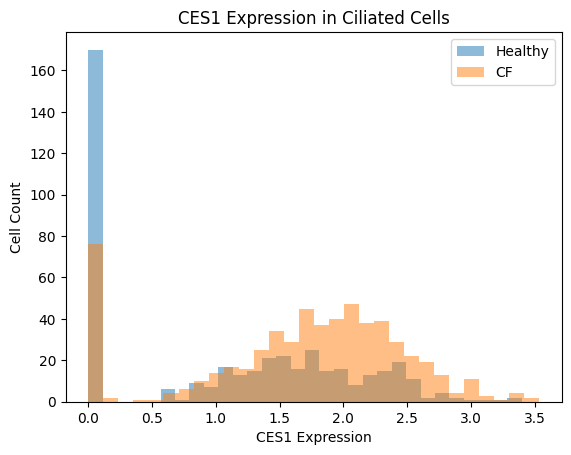

In [10]:
import matplotlib.pyplot as plt

plt.hist(
    healthy_ces1,
    bins=30,
    alpha=0.5,
    label="Healthy"
)

plt.hist(
    cf_ces1,
    bins=30,
    alpha=0.5,
    label="CF"
)

plt.legend()
plt.xlabel("CES1 Expression")
plt.ylabel("Cell Count")
plt.title("CES1 Expression in Ciliated Cells")

plt.show()

Generates a histogram plot of the gene expression levels for the CES1 gene in both healthy and diseased cells. The healthy cells have mostly lower levels of expression, but there is a lot of overlap. 

In [11]:
sys.path.append("../src");

from cells import gene_detection_difference

detection_df = gene_detection_difference(
    healthy,
    cf
)

detection_df[
    detection_df["gene"] == "CES1"]

,gene,healthy_detected,diseased_detected,detection_difference,abs_detection_difference
4,CES1,0.606481,0.870968,0.264486,0.264486


In [12]:
gene_df.head(20)

,gene,healthy_mean,diseased_mean,difference,abs_difference
0,FTL,2.224556,1.563133,-0.661423,0.661423
1,CES1,1.061965,1.665091,0.603126,0.603126
2,XIST,0.044804,0.591547,0.546743,0.546743
3,RPS4Y1,0.879403,0.343533,-0.535870,0.535870
4,TMEM190,2.576251,3.070320,0.494069,0.494069
5,IFI27,2.947283,2.474696,-0.472587,0.472587
6,CLU,2.378790,1.953092,-0.425698,0.425698
7,KLF6,0.692946,1.096312,0.403366,0.403366
8,PIGR,2.055740,2.453878,0.398137,0.398137
9,JUN,0.896795,1.274289,0.377493,0.377493


In [13]:
detection_df.head(20)

,gene,healthy_detected,diseased_detected,detection_difference,abs_detection_difference
0,XIST,0.032407,0.414261,0.381854,0.381854
1,RPS4Y1,0.585648,0.249576,-0.336073,0.336073
2,METTL27,0.224537,0.512733,0.288196,0.288196
3,GBP3,0.231481,0.516129,0.284648,0.284648
4,CES1,0.606481,0.870968,0.264486,0.264486
5,KLF6,0.474537,0.707980,0.233443,0.233443
6,DNAH2,0.356481,0.582343,0.225861,0.225861
7,NELL2,0.108796,0.329372,0.220576,0.220576
8,SYTL2,0.398148,0.617997,0.219848,0.219848
9,DDX3X,0.446759,0.665535,0.218776,0.218776


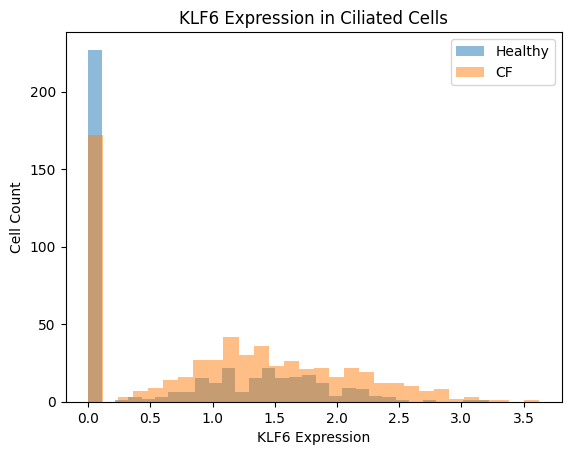

In [14]:
healthy_klf6 = get_gene_expression(
    healthy,"KLF6")

cf_klf6 = get_gene_expression(
cf, "KLF6")

healthy_klf6.mean()
cf_klf6 = get_gene_expression(
cf, "KLF6")

healthy_klf6.mean()

plt.hist(
    healthy_klf6,
    bins=30,
    alpha=0.5,
    label="Healthy"
)

plt.hist(
    cf_klf6,
    bins=30,
    alpha=0.5,
    label="CF"
)

plt.legend()
plt.xlabel("KLF6 Expression")
plt.ylabel("Cell Count")
plt.title("KLF6 Expression in Ciliated Cells")

plt.show()

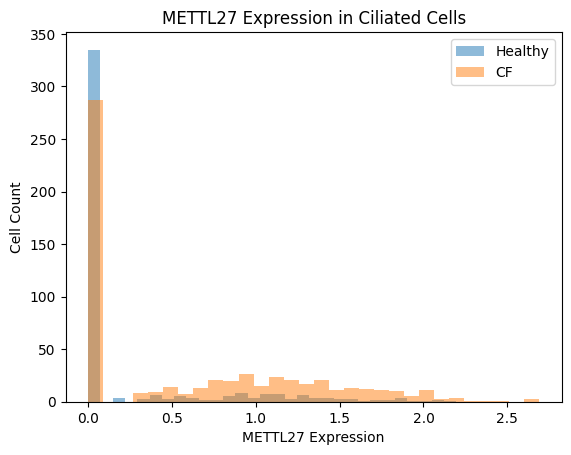

In [15]:
healthy_mettl27 = get_gene_expression(
    healthy,"METTL27")

cf_mettl27 = get_gene_expression(
cf, "METTL27")

healthy_mettl27.mean()
cf_mettl27 = get_gene_expression(
cf, "METTL27")

healthy_mettl27.mean()

plt.hist(
    healthy_mettl27,
    bins=30,
    alpha=0.5,
    label="Healthy"
)

plt.hist(
    cf_mettl27,
    bins=30,
    alpha=0.5,
    label="CF"
)

plt.legend()
plt.xlabel("METTL27 Expression")
plt.ylabel("Cell Count")
plt.title("METTL27 Expression in Ciliated Cells")

plt.show()

Based on the rankings of each of the genes present in the analysis, the genes CES1, KLF6, and METTL27 were selected as preliminary candidates for a future rule-based classifier. These genes demonstrated changes across multiple metric and will be investigated further to determine suitable classification threshholds. For now, I may consider making the rules in my rule-based classifier centered on the amount of genes expressed rather than the expression of the genes. 